In [ ]:
"""
    - Importaciones necesarias.
"""
import numpy as np
import numpy.typing as npt
import random
import matplotlib.pyplot as plt # Poder crear graficos
from matplotlib.ticker import PercentFormatter # Crear porcentajes.

In [ ]:
"""
    - Función que imprime al individuo en representación de tablero en formato textual
"""

def imprimir_tablero(individuo:list, N: int=8) -> None:
    # Imprimir formato de tablero
    if individuo:
        for i in range(N):
            linea = ""
            for j in range(N):
                if individuo[j] == i:
                    linea += "Q "
                else:
                    linea += ". "
            print(linea)

In [23]:

"""
    - Guardamos el minimo, maximo y el promedio en cada epoca del fitness.
    - Lo ponemos de esta manera para poder tenerlos de forma global.
"""

# TODO: Guardamos el minimo, maximo y el promedio en cada epoca del fitness. 
valor_minimo_generacion: npt.NDArray[np.int8] = []
valor_maximo_generacion: npt.NDArray[np.int8] = []
valor_promedio_generacion: npt.NDArray[np.int8] = []


In [36]:

def generar_poblacion() -> npt.NDArray[np.int8]:
    """
    Genera una población aleatoria.

    Retorna
    -------
    npt.NDArray[np.int8]
        Matriz de numpy de forma (100, 8)
        - 100 individuos
        - 8 genes por individuo
        - valores entre 0 y 7
    """
    # TODO: Generar una población aleatoria conformada por individuos que contienen 8 genes.
    # Cada dimensión representa la columna de la posición de la reina, se tiene como máximo 8 columnas.
    # El valor del gen representa la fila donde está colocada la reina, se tiene los valores 0-7,
    # considerando el cero como la primera fila.

    poblacion: npt.NDArray[np.int8] = []

    for i in range(100):
         poblacion.append(np.random.choice(8, 8, replace=False))


    #poblacion: npt.NDArray[np.int8] = np.random.randint(0,8,(100,8))
    return poblacion

def calcular_aptitud(individuo: npt.NDArray[np.int8]) -> int:
    """Calcula el número de conflictos (aptitud o fitness)."""
    # TODO: Calcula el número de conflictos si un par de reinas están en la misma fila
    # o si están en la misma diagonal.
    # No pueden estar en la misma columna debido a que la representación no lo permite,
    # solo hay una reina por columna.

    conflictos: int = 0
    for i in range(0,8):
        for k in range(i+1,8):

            if individuo[i] == individuo[k]:
                conflictos = conflictos + 1
            
            if abs(i-k) == abs(individuo[i]-individuo[k]):
                conflictos = conflictos + 1 
    
    return conflictos


def seleccionar_padres(
    poblacion: npt.NDArray[np.int8]
) -> tuple[npt.NDArray[np.int8], npt.NDArray[np.int8]]:
    """Selecciona dos padres usando selección por torneo."""

    # TODO: Seleccionar de forma aleatoria 4 individuos
    # Sugerencia usar: random.sample
    seleccionados = random.sample(list(poblacion),4)
    candidatos_array_ordenados:npt.NDArray = sorted(seleccionados, key=lambda x:x[1]) 
    torneo: npt.NDArray = candidatos_array_ordenados[:2] 

    # Ordenar a los individuos seleccionados de acuerdo a la aptitud y seleccionar a los 2 mejores
    padre1: tuple[np.array,int] = torneo[0] 
    padre2: tuple[np.array,int] = torneo[1]
    

    
    return padre1, padre2

def cruzar(
    padre1: npt.NDArray[np.int8],
    padre2: npt.NDArray[np.int8]
) -> tuple[npt.NDArray[np.int8], npt.NDArray[np.int8]]:
    """Realiza crossover entre dos padres."""

    punto_cruce: int = np.random.randint(0,8)
    padre1= padre1[0]
    padre2= padre2[0]

    # TODO: Obtener un punto de cruza aleatorio y obtener dos hijos
    hijo1: npt.NDArray[np.int_] = np.concatenate((padre1[:punto_cruce],padre2[punto_cruce:]))
    hijo2: npt.NDArray[np.int_] = np.concatenate((padre2[:punto_cruce],padre1[punto_cruce:]))

    return hijo1, hijo2


def mutar(
    individuo: npt.NDArray[np.int8],
    tasa_mutacion: float = 0.1
) -> npt.NDArray[np.int8]:
    """Realiza mutación con una probabilidad dada."""

    if np.random.random() < tasa_mutacion:
        # Se aplica la mutación, solo si pasó el umbral aleatorio.

        # TODO: obtener de forma aleatoria la posición del gen por sustituir,
        # con un nuevo valor aleatorio dentro del rango permitido [0, 7]
        gen_mutacion: int = np.random.randint(0,8) 
        posicion_mutacion: int = np.random.randint(0,8)
        individuo: npt.NDArray[np.int8]

        individuo[posicion_mutacion] = gen_mutacion
        

    return individuo

def algoritmo_genetico() -> npt.NDArray[np.int8] | None:
    """Resuelve el problema de las 8 reinas usando un algoritmo genético."""

    # Parámetros
    # TODO: Definir los parámetros
    tamano_poblacion: int = 100
    max_generaciones: int = 300
    tasa_mutacion: float = 0.1

    # TODO: Generar población inicial
    poblacion: npt.NDArray[np.int8] = generar_poblacion()


    for generacion in range(max_generaciones):

        # TODO: Calcular aptitudes de toda la población para verificar si ya hay una solución
        aptitudes:list[int] = []
        for individuo in poblacion:
            aptitudes.append(calcular_aptitud(individuo))

        # TODO: Calculamos el minimo, maxio y el promedio de la generación
        valor_maximo_generacion.append(np.max(aptitudes))
        valor_minimo_generacion.append(np.min(aptitudes))
        valor_promedio_generacion.append(np.mean(aptitudes))

        # TODO: Verificar si hay solución
        # Si hay solución termina el algoritmo, y retornar la solución
        # De lo contrario continua con el proceso de evolución
        for indice in range(0, len(aptitudes)):
            if aptitudes[indice] == 0:
                print("Existe una solucion en el tablero")
                print(f"Se encontro la solución en la generación {generacion}")
                return poblacion[indice]
           
        # Nueva generación
        nueva_poblacion: list[npt.NDArray[np.int8]] = []

        padre1: npt.NDArray[np.int8]
        padre2: npt.NDArray[np.int8]
        hijo1: npt.NDArray[np.int8]
        hijo2: npt.NDArray[np.int8]
        #
        poblacion_fitness: list[tuple[list[int], float]] = []

        for posicion in range(0,len(poblacion)):
            poblacion_fitness.append((poblacion[posicion],aptitudes[posicion]))
    

        for _ in range(tamano_poblacion // 2):
            padre1, padre2 = seleccionar_padres(poblacion_fitness)

            hijo1, hijo2 = cruzar(padre1, padre2)

            hijo1 = mutar(hijo1, tasa_mutacion)
            hijo2 = mutar(hijo2, tasa_mutacion)

            # Construye a la nueva población con los hijos
            nueva_poblacion.append(hijo1)
            nueva_poblacion.append(hijo2)

        # Sustituye a la población completa de padres por los hijos
        poblacion = np.array(nueva_poblacion, dtype=np.int8)

    print("No se encontró solución en el número máximo de generaciones.")
    return None

In [37]:
# Ejecutar el algoritmo genético
solucion: npt.NDArray[np.int8] | None = algoritmo_genetico()

if solucion is not None:
    print(solucion)
    imprimir_tablero(list(solucion))

Existe una solucion en el tablero
Se encontro la solución en la generación 20
[3 7 4 2 0 6 1 5]
. . . . Q . . . 
. . . . . . Q . 
. . . Q . . . . 
Q . . . . . . . 
. . Q . . . . . 
. . . . . . . Q 
. . . . . Q . . 
. Q . . . . . . 


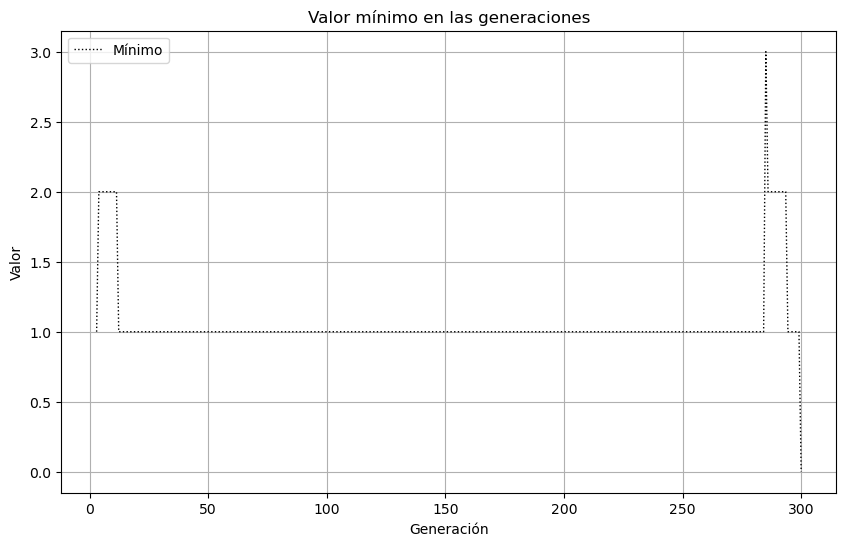

In [20]:
minimo = np.min(valor_minimo_generacion)
maximo = np.max(valor_minimo_generacion)


x = np.linspace(maximo,300,len(valor_minimo_generacion))

plt.figure(figsize=(10,6))
plt.plot(x,valor_minimo_generacion, label = 'Mínimo', color='black', linestyle=':', linewidth=1)

# Añadir título y etiquetas
plt.title('Valor mínimo en las generaciones')
plt.xlabel('Generación')
plt.ylabel('Valor')

# Añadir una leyenda
plt.legend()

# Mostrar el gráfico
plt.grid(True)
plt.show()

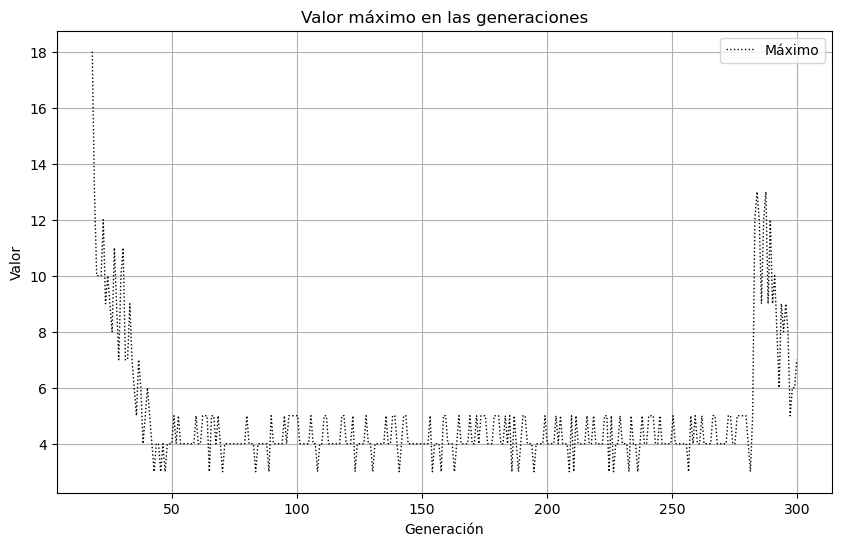

In [21]:
minimo = np.min(valor_maximo_generacion)
maximo = np.max(valor_maximo_generacion)


x = np.linspace(maximo,300,len(valor_maximo_generacion))

plt.figure(figsize=(10,6))
#plt.plot(x, y1, label='Seno', color='orange', linestyle=':', linewidth=2)
plt.plot(x,valor_maximo_generacion, label = 'Máximo', color='black', linestyle=':', linewidth=1)

# Añadir título y etiquetas
plt.title('Valor máximo en las generaciones')
plt.xlabel('Generación')
plt.ylabel('Valor')

# Añadir una leyenda
plt.legend()

# Mostrar el gráfico
plt.grid(True)
plt.show()

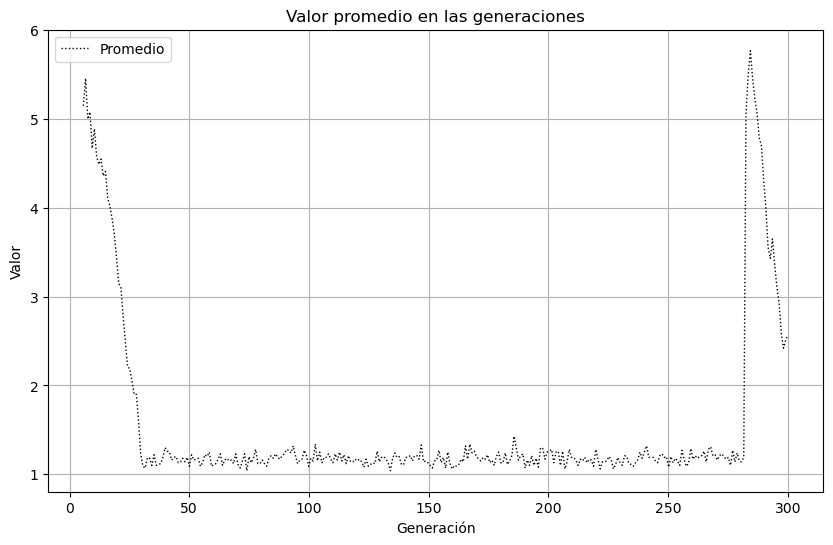

1.55384375


In [22]:
minimo = np.min(valor_promedio_generacion)
maximo = np.max(valor_promedio_generacion)


x = np.linspace(maximo,300,len(valor_promedio_generacion))

plt.figure(figsize=(10,6))
#plt.plot(x, y1, label='Seno', color='orange', linestyle=':', linewidth=2)
plt.plot(x,valor_promedio_generacion, label = 'Promedio', color='black', linestyle=':', linewidth=1)

# Añadir título y etiquetas
plt.title('Valor promedio en las generaciones')
plt.xlabel('Generación')
plt.ylabel('Valor')

# Añadir una leyenda
plt.legend()

# Mostrar el gráficomaximo
plt.grid(True)
plt.show()

print(np.mean(valor_promedio_generacion))

In [10]:
datos_exito = np.zeros(100)
print(datos_exito)

for ejecucion in range(100):

    solucion: npt.NDArray[np.int8] | None = algoritmo_genetico()

    if solucion is not None:
        datos_exito[ejecucion] = 1


[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
Existe una solucion en el tablero
Se encontro la solución en la generación 0
No se encontró solución en el número máximo de generaciones.
Existe una solucion en el tablero
Se encontro la solución en la generación 0
Existe una solucion en el tablero
Se encontro la solución en la generación 0
Existe una solucion en el tablero
Se encontro la solución en la generación 2
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
Existe una solucion en el tablero
Se encontro la solución en la generación 61
No se encontró solución en el número máximo de generaciones.
No se encontró solución en el número máximo de generaciones.
Exi

In [11]:
# Calcular el porcentaje
suma_exito = np.sum(datos_exito)
porcentajes = (suma_exito / 100) * 100

print(f"El porcentaje de éxito fue: {porcentajes} %")

_promedio = np.mean(datos_exito) 
_desviacion_estandar = np.std(datos_exito)

print(f"Promedio de éxito es {_promedio}")
print(f"Desviación estandar del exito es {_desviacion_estandar}")


El porcentaje de éxito fue: 60.0 %
Promedio de éxito es 0.6
Desviación estandar del exito es 0.48989794855663565


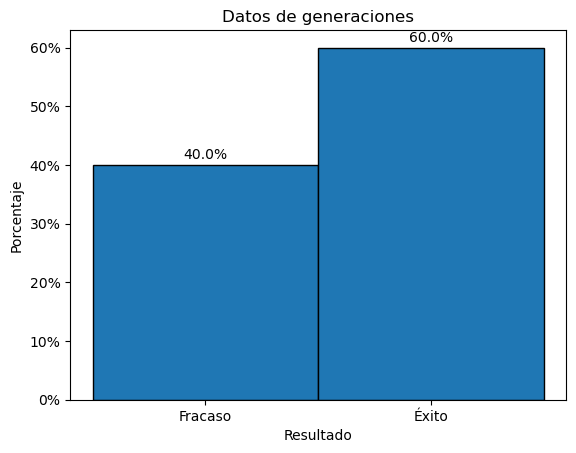

In [12]:
"""
    Grafico del histograma.
"""
# Manejo de procentajes.
from matplotlib.ticker import PercentFormatter


# Intervalos de 0 y 1
intervalos = [0,1]
# Pesos, convierte las frecuencias en porcentajes.
weights = np.ones(len(datos_exito)) / len(datos_exito)
# bins centrados en 0 y 1 donde caerán los datos. 
bins = [-0.5, 0.5, 1.5]

# n -> Contiene la altura.
# bins -> Intervalos usados.
# patches -> Objeto gráficos de cada barra. 
n, bins, patches = plt.hist(datos_exito, bins=bins, edgecolor='black', weights=weights)

plt.title("Datos de generaciones")
plt.xlabel("Resultado")
plt.ylabel("Porcentaje")

# Etiquetas del eje X
plt.xticks(intervalos, ["Fracaso", "Éxito"])

# Convertimos el eje Y en porcentajes.
# Get Current Axes
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))


# porcentaje encima de cada barra
for i in range(len(patches)):
    # Sacamos la altura de la barra.
    altura = n[i]
    # Esto obtiene el centro de la barra para colocar el texto.
    x = patches[i].get_x() + patches[i].get_width()/2
    # Escribimos la altura de  
    plt.text(x, altura + 0.01, f"{altura*100:.1f}%", ha='center')

plt.show()